# ASHA Sahayak — GRPO Training

**Environment**: [ASHA Sahayak HF Space](https://sreenathmmenon-asha-sahayak.hf.space)  
**Algorithm**: GRPO via TRL  
**Efficiency**: Unsloth when GPU available, plain TRL as fallback  
**Base model**: Qwen/Qwen3-0.6B  
**Ground truth**: Indian Government IMNCI Protocol  

## Requirements
- **GPU runtime** (Runtime → Change runtime type → T4 GPU) — free Colab tier is sufficient
- HuggingFace token with write access (for pushing trained model to Hub)
- No premium subscription required for training

## What this notebook does
1. Installs Unsloth (GPU-accelerated) or plain TRL (CPU fallback)
2. Connects to live ASHA Sahayak environment
3. Runs GRPO training — model learns to ask right questions and make correct referrals
4. Plots real reward curves from actual training
5. Pushes trained model to HuggingFace Hub

In [1]:
%%capture
import os
os.environ["UNSLOTH_VLLM_STANDBY"] = "1"

# Remove conflicting pre-installed packages before any GPU lib loads
import subprocess
subprocess.run(["pip", "uninstall", "-y", "torchvision", "torchcodec"], capture_output=True)

if "COLAB_" not in "".join(os.environ.keys()):
    !pip install unsloth vllm
else:
    # Install uv FIRST — must be available before the lines below run
    !pip install --upgrade -qqq uv
    try: import numpy, PIL; _numpy = f'numpy=={numpy.__version__}'; _pil = f'pillow=={PIL.__version__}'
    except: _numpy = "numpy"; _pil = "pillow"
    try: import subprocess; is_t4 = "Tesla T4" in str(subprocess.check_output(["nvidia-smi"]))
    except: is_t4 = False
    # T4: vllm==0.9.2 (PyTorch 2.7), L4/A100: vllm==0.15.1 (PyTorch 2.10+, fixes cudaErrorIllegalAddress bug)
    # Source: official Unsloth Qwen3 GRPO notebook (github.com/unslothai/notebooks)
    _vllm, _triton = ('vllm==0.9.2', 'triton==3.2.0') if is_t4 else ('vllm==0.15.1', 'triton')
    !uv pip install -qqq --upgrade {_vllm} {_numpy} {_pil} bitsandbytes xformers unsloth unsloth_zoo
    !uv pip install -qqq {_triton}
    !uv pip install -qqq transformers==4.56.2
    !uv pip install -qqq --no-deps trl==0.22.2
    !uv pip install -qqq accelerate peft httpx datasets matplotlib tqdm

In [2]:
# ── Cell 2: Configuration ────────────────────────────────────────────────────
import os

# Must be set before any GPU library imports (unsloth imported in Cell 4)
os.environ["PYTORCH_ALLOC_CONF"] = ""
os.environ["UNSLOTH_VLLM_STANDBY"] = "1"

# ── HF Token ─────────────────────────────────────────────────────────────────
try:
    from google.colab import userdata
    HF_TOKEN = userdata.get('HF_TOKEN') or ''
except Exception:
    HF_TOKEN = os.getenv('HF_TOKEN', '')

assert HF_TOKEN, "HF_TOKEN not found. Add it via Colab Secrets (left sidebar → 🔑)"

ENV_BASE_URL     = 'https://sreenathmmenon-asha-sahayak.hf.space'
HF_REPO_ID       = 'sreenathmmenon/asha-sahayak-grpo'
BASE_MODEL       = 'Qwen/Qwen3-0.6B'
OUTPUT_DIR       = 'asha-sahayak-grpo'
NUM_TRAIN_STEPS  = 200
LEARNING_RATE    = 5e-6
NUM_GENERATIONS  = 4
MAX_SEQ_LEN      = 2048

print('Config loaded ✓')
print(f'Environment: {ENV_BASE_URL}')
print(f'Base model: {BASE_MODEL}')
print('HF Token: loaded ✓')

Config loaded ✓
Environment: https://sreenathmmenon-asha-sahayak.hf.space
Base model: Qwen/Qwen3-0.6B
HF Token: loaded ✓


In [3]:
import httpx
# ── Cell 3: ASHA Environment client + TRL-compatible wrapper ─────────────────
from typing import Optional

class AshaClient:
    """Thin HTTP client for the ASHA Sahayak OpenEnv environment."""

    def __init__(self, base_url: str = ENV_BASE_URL):
        self.base_url = base_url.rstrip('/')
        self.session_id: Optional[str] = None

    def reset(self, task_id: str = 'easy', seed: int = 42) -> dict:
        resp = httpx.post(
            f'{self.base_url}/reset',
            json={'task_id': task_id, 'seed': seed},
            timeout=30,
        )
        resp.raise_for_status()
        data = resp.json()
        self.session_id = data['session_id']
        return data

    def step(self, *, referral_decision: str = 'PENDING', urgency: str = 'monitor',
             primary_concern: str = '', question: Optional[str] = None,
             confidence: float = 0.8) -> dict:
        headers = {'X-Session-ID': self.session_id} if self.session_id else {}
        resp = httpx.post(
            f'{self.base_url}/step',
            json={'referral_decision': referral_decision, 'urgency': urgency,
                  'primary_concern': primary_concern, 'question': question,
                  'confidence': confidence},
            headers=headers,
            timeout=30,
        )
        resp.raise_for_status()
        return resp.json()['observation']


class AshaToolEnv:
    """
    TRL-compatible RL environment for ASHA Sahayak.

    TRL discovers public methods as callable tools via their docstrings.
    reset() is called at episode start; reward is read from self.reward.
    """

    def __init__(self):
        self.client = AshaClient()
        self.reward: float = 0.0
        self._done: bool = False

    def reset(self, task_id: str = 'easy', seed: int = 42, **_) -> str:
        """Reset to a new clinical case. Called automatically by TRL."""
        self.reward = 0.0
        self._done = False
        data = self.client.reset(task_id=task_id, seed=seed)
        return data['observation']['conversation'][0]['text']

    def ask_question(self, question: str) -> str:
        """Ask the ASHA worker a clinical clarifying question.

        Args:
            question: Clinical question, e.g. 'Does the child have fast breathing?'

        Returns:
            ASHA worker's clinical observation in response to the question.
        """
        if self._done:
            return 'Episode already ended. No more questions.'
        obs = self.client.step(referral_decision='PENDING', question=question)
        self.reward = obs.get('reward', 0.0)
        self._done = obs.get('done', False)
        convo = obs.get('conversation', [])
        return convo[-1]['text'] if convo else 'No response.'

    def make_referral(
        self,
        referral_decision: str,
        urgency: str,
        primary_concern: str,
        confidence: float = 0.8,
    ) -> str:
        """Make the final clinical referral decision for the patient.

        Args:
            referral_decision: REFER_IMMEDIATELY | REFER_WITHIN_24H | TREAT_AT_HOME | MONITOR
            urgency: immediate | within_24h | routine | monitor
            primary_concern: Clinical condition, e.g. severe_pneumonia, pre_eclampsia
            confidence: Confidence score 0.0-1.0

        Returns:
            Clinical feedback with score breakdown.
        """
        if self._done:
            return 'Episode already ended.'
        obs = self.client.step(
            referral_decision=referral_decision, urgency=urgency,
            primary_concern=primary_concern, confidence=confidence,
        )
        self.reward = obs.get('reward', 0.0)
        self._done = obs.get('done', False)
        return obs.get('feedback') or f'Score: {self.reward:.3f}'


# Smoke test
env = AshaToolEnv()
obs = env.reset(task_id='easy', seed=42)
print('Case:', obs[:200])
resp = env.ask_question('Does the child have fast breathing or chest indrawing?')
print('Response:', resp[:150])
fb = env.make_referral('REFER_IMMEDIATELY', 'immediate', 'severe_pneumonia')
print('Feedback:', fb[:150])
print(f'Reward: {env.reward:.4f}')

# Verify environment connectivity
_r = httpx.get(f'{ENV_BASE_URL}/health', timeout=30)
assert _r.status_code == 200 and _r.json()['status'] == 'healthy', f'Env not reachable: {_r.text}'
_meta = httpx.get(f'{ENV_BASE_URL}/metadata', timeout=30).json()
print(f"Environment: {_meta['num_cases']} cases | {_meta['tasks']} tasks | concurrent: {_meta['supports_concurrent_sessions']}")

Case: 4 saal ke bachche ko 2 din se dast ho raha hai. Maa pareshan hai.
[A 4-year-old child has been having diarrhea for 2 days. Mother is worried.]
Response: Didi, koi aur khaas baat nahi dikh rahi abhi. Jo bataya hai wahi hai.
[Sister, no other special signs visible right now. What I told you is all.]
Feedback: CASE: Mild Diarrhea — Home Care

Your decision:    REFER_IMMEDIATELY (immediate)
Correct decision: TREAT_AT_HOME (routine)

Scores:
  Referral decisio
Reward: 0.2800
Environment: 31 cases | ['easy', 'medium', 'hard'] tasks | concurrent: True


In [4]:
# ── Cell 4: Load model ───────────────────────────────────────────────────────
# CRITICAL: from unsloth import must be FIRST — torch comes after
# Matches official Unsloth Qwen3-GRPO notebook import order exactly.

HAS_GPU = False
USE_UNSLOTH = False

try:
    from unsloth import FastLanguageModel  # unsloth FIRST
    import torch                           # torch SECOND
    HAS_GPU = torch.cuda.is_available()
    USE_UNSLOTH = HAS_GPU
except ImportError:
    import torch
    HAS_GPU = torch.cuda.is_available()
    USE_UNSLOTH = False

COMPUTE_DTYPE = torch.bfloat16 if (HAS_GPU and torch.cuda.is_bf16_supported()) else torch.float16
print(f'GPU: {torch.cuda.get_device_name(0) if HAS_GPU else "None (CPU)"}')
print(f'Compute dtype: {COMPUTE_DTYPE}')
print(f'Backend: {"Unsloth + vLLM" if USE_UNSLOTH else "Plain TRL (CPU)"}')

if USE_UNSLOTH:
    model, tokenizer = FastLanguageModel.from_pretrained(
        model_name=BASE_MODEL,
        max_seq_length=MAX_SEQ_LEN,
        load_in_4bit=False,
        fast_inference=True,
        max_lora_rank=64,
        gpu_memory_utilization=0.6,
    )
    model = FastLanguageModel.get_peft_model(
        model,
        r=32,
        target_modules=['q_proj', 'k_proj', 'v_proj', 'o_proj',
                        'gate_proj', 'up_proj', 'down_proj'],
        lora_alpha=64,
        lora_dropout=0.0,
        bias='none',
        use_gradient_checkpointing='unsloth',
        random_state=42,
    )
    print('Model loaded: Unsloth 16-bit LoRA + vLLM ✓')
else:
    from transformers import AutoModelForCausalLM, AutoTokenizer
    from peft import LoraConfig, get_peft_model
    tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL, trust_remote_code=True)
    model = AutoModelForCausalLM.from_pretrained(
        BASE_MODEL,
        torch_dtype=COMPUTE_DTYPE,
        device_map='auto' if HAS_GPU else 'cpu',
        trust_remote_code=True,
    )
    lora_cfg = LoraConfig(
        r=32, lora_alpha=64, lora_dropout=0.0, bias='none',
        target_modules=['q_proj', 'v_proj', 'k_proj', 'o_proj'],
        task_type='CAUSAL_LM',
    )
    model = get_peft_model(model, lora_cfg)
    print('Model loaded: plain TRL 16-bit LoRA ✓')

model.print_trainable_parameters()

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
GPU: NVIDIA L4
Compute dtype: torch.bfloat16
Backend: Unsloth + vLLM
INFO 04-25 10:30:39 [vllm_utils.py:724] Unsloth: Patching vLLM v1 graph capture
==((====))==  Unsloth 2026.4.8: Fast Qwen3 patching. Transformers: 4.56.2. vLLM: 0.15.1.
   \\   /|    NVIDIA L4. Num GPUs = 1. Max memory: 22.034 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.9.1+cu128. CUDA: 8.9. CUDA Toolkit: 12.8. Triton: 3.5.1
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.33.post2. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
Unsloth: Standby mode is enabled. Changing `gpu_memory_utilization` to 0.78375.
Unsloth: vLLM loading unsloth/Qwen3-0.6B with actual GPU utilization = 77.56%
Unsloth: Your GPU has CUDA compute capability 8.9 with VRAM = 22.03 GB.
Unsloth: Usin

/usr/local/lib/python3.12/dist-packages/pydantic/type_adapter.py:607: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `enum` - serialized value may not be as expected [field_name='mode', input_value=3, input_type=int])
  return self.serializer.to_python(


INFO 04-25 10:31:04 [model.py:541] Resolved architecture: Qwen3ForCausalLM
INFO 04-25 10:31:04 [model.py:1561] Using max model len 2048
INFO 04-25 10:31:05 [scheduler.py:226] Chunked prefill is enabled with max_num_batched_tokens=6144.
INFO 04-25 10:31:05 [vllm.py:624] Asynchronous scheduling is enabled.


generation_config.json:   0%|          | 0.00/237 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

...

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

chat_template.jinja: 0.00B [00:00, ?B/s]

unsloth/Qwen3-0.6B does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.


Unsloth 2026.4.8 patched 28 layers with 28 QKV layers, 28 O layers and 28 MLP layers.


Model loaded: Unsloth 16-bit LoRA + vLLM ✓
trainable params: 20,185,088 || all params: 616,235,008 || trainable%: 3.2756


In [5]:
# ── Cell 5: Training dataset ─────────────────────────────────────────────────
import random
from datasets import Dataset

SYSTEM_PROMPT = """You are an AI assistant helping ASHA (Accredited Social Health Activist) workers in rural India make clinical triage decisions using the IMNCI protocol.

Your workflow:
1. Ask clarifying questions with ask_question() to gather clinical information
2. Make your final decision with make_referral():
   - REFER_IMMEDIATELY: Life-threatening — call 108 now
   - REFER_WITHIN_24H: Needs PHC within 24 hours
   - TREAT_AT_HOME: Manage at home with ASHA guidance
   - MONITOR: Observe and follow up

Always ask at least one clarifying question before deciding.
Key danger signs: fast breathing, chest indrawing, inability to feed, convulsions, unconsciousness, severe bleeding, very low weight."""

USER_PROMPT = "A patient has been presented to you. Please assess and make a clinical triage decision."

random.seed(42)
rows = []

for seed in range(50):   rows.append({'task_id': 'easy',   'seed': seed})
for seed in range(100):  rows.append({'task_id': 'medium', 'seed': seed})
for seed in range(75):   rows.append({'task_id': 'hard',   'seed': seed})

random.shuffle(rows)

dataset = Dataset.from_list([
    {
        'prompt': [
            {'role': 'system', 'content': SYSTEM_PROMPT},
            {'role': 'user',   'content': USER_PROMPT},
        ],
        'task_id': r['task_id'],
        'seed':    r['seed'],
    }
    for r in rows
])

counts = {t: sum(1 for r in rows if r['task_id'] == t) for t in ['easy', 'medium', 'hard']}
print(f'Dataset: {len(dataset)} episodes')
for t, n in counts.items():
    print(f'  {t}: {n}')

Dataset: 225 episodes
  easy: 50
  medium: 100
  hard: 75


In [6]:
# ── Cell 6: GRPO Training ─────────────────────────────────────────────────────
import os, re, torch, traceback
from concurrent.futures import ThreadPoolExecutor, as_completed
os.environ['TRL_EXPERIMENTAL_SILENCE'] = '1'

from trl import GRPOTrainer, GRPOConfig

REFERRALS = ["REFER_IMMEDIATELY", "REFER_WITHIN_24H", "TREAT_AT_HOME", "MONITOR"]
URGENCIES  = ["immediate", "within_24h", "routine", "monitor"]

def parse_and_score(text: str, task_id: str, seed: int) -> float:
    """Parse model output and score it against the ASHA environment."""
    text_upper = text.upper()
    referral = next((r for r in REFERRALS if r in text_upper), "MONITOR")
    urgency  = next((u for u in URGENCIES  if u in text.lower()), "monitor")

    # Extract primary concern
    concern_match = re.search(r'(?:concern|diagnosis|condition)[:\s]+([a-z_]+)', text.lower())
    concern = concern_match.group(1) if concern_match else "general"

    # Extract question if present
    question_match = re.search(r'(?:question|ask)[:\s]+"?([^"\n]{10,150})"?', text.lower())
    question = question_match.group(1) if question_match else None

    env = AshaToolEnv()
    env.reset(task_id=task_id, seed=seed)
    if question and not env._done:
        env.ask_question(question)
    if not env._done:
        env.make_referral(referral, urgency, concern)
    return float(env.reward)


def _score_one(i, completion, task_id_list, seed_list):
    """Score a single completion — called from thread pool."""
    try:
        text = completion[0]['content'] if isinstance(completion, list) else str(completion)
        tid  = task_id_list[i] if task_id_list else 'easy'
        sd   = int(seed_list[i]) if seed_list else i
        return i, parse_and_score(text, tid, sd)
    except Exception as e:
        print(f"[reward] completion {i} failed: {e}")
        traceback.print_exc()
        return i, 0.0


def reward_func(prompts, completions, completion_ids, task_id=None, seed=None, **kwargs):
    n = len(completions)
    results = [0.0] * n
    with ThreadPoolExecutor(max_workers=min(n, 8)) as pool:
        futures = {pool.submit(_score_one, i, completions[i], task_id, seed): i for i in range(n)}
        for future in as_completed(futures):
            idx, reward = future.result()
            results[idx] = reward
    return results


# ── Pre-training smoke test ──────────────────────────────────────────────────
print("Smoke test: verifying reward scoring before training starts...")
_test_completions = [
    [{"role": "assistant", "content": "Question: Does the child have fast breathing? REFER_IMMEDIATELY urgency immediate concern severe_pneumonia"}],
    [{"role": "assistant", "content": "TREAT_AT_HOME urgency routine diagnosis pneumonia"}],
]
_test_rewards = reward_func(
    prompts=["dummy", "dummy"],
    completions=_test_completions,
    completion_ids=["dummy", "dummy"],
    task_id=["easy", "easy"],
    seed=[42, 42],
)
print(f"  Smoke test rewards: {[round(r,4) for r in _test_rewards]}")
assert any(r != 0.0 for r in _test_rewards), (
    "ABORT: All smoke test rewards are 0.0 — environment is not reachable or scoring is broken. "
    "Check Cell 2 ENV_BASE_URL and that the HF Space is running."
)
print("  Smoke test passed ✓  (rewards are non-zero)")
print()

# ── GRPOConfig ───────────────────────────────────────────────────────────────
# trl==0.22.2 — max_prompt_length is valid in this version
config = GRPOConfig(
    use_vllm=True,
    output_dir=OUTPUT_DIR,
    max_steps=NUM_TRAIN_STEPS,
    num_generations=NUM_GENERATIONS,
    per_device_train_batch_size=1,
    gradient_accumulation_steps=8,
    max_prompt_length=512,
    max_completion_length=512,
    learning_rate=LEARNING_RATE,
    warmup_ratio=0.1,
    lr_scheduler_type='cosine',
    optim='adamw_8bit',
    max_grad_norm=0.1,
    logging_steps=1,
    save_steps=50,
    report_to='none',
    seed=42,
)

trainer = GRPOTrainer(
    model=model,
    args=config,
    train_dataset=dataset,
    processing_class=tokenizer,
    reward_funcs=reward_func,
)

print(f'Starting GRPO training ({NUM_TRAIN_STEPS} steps)...')
print(f'GPU: {torch.cuda.get_device_name(0) if HAS_GPU else "None"}')
trainer.train()
print('Training complete!')

Smoke test: verifying JSON extraction and reward scoring...
  referral=REFER_IMMEDIATELY urgency=immediate concern=severe_pneumonia question=Does the child have chest indrawing?
  referral=TREAT_AT_HOME urgency=routine concern=pneumonia question=None
  referral=REFER_IMMEDIATELY urgency=immediate concern=severe_pneumonia question=does the child have fast breathing? refe
  Smoke test rewards: [0.38, 0.74]
  Smoke test passed ✓

Starting GRPO training (200 steps)...
GPU: NVIDIA L4


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 225 | Num Epochs = 2 | Total steps = 200
O^O/ \_/ \    Batch size per device = 1 | Gradient accumulation steps = 8
\        /    Data Parallel GPUs = 1 | Total batch size (1 x 8 x 1) = 8
 "-____-"     Trainable parameters = 20,185,088 of 616,235,008 (3.28% trained)


WARNING 04-25 12:14:34 [input_processor.py:287] vLLM has deprecated support for supporting different tokenizers for different LoRAs. By default, vLLM uses base model's tokenizer. If you are using a LoRA with its own tokenizer, consider specifying `--tokenizer [lora_path]` to use the LoRA tokenizer.
Unsloth: Will smartly offload gradients to save VRAM!


Step,Training Loss,reward,reward_std,completions / mean_length,completions / min_length,completions / max_length,completions / clipped_ratio,completions / mean_terminated_length,completions / min_terminated_length,completions / max_terminated_length,kl,rewards / reward_func / mean,rewards / reward_func / std
1,0.000000,0.310000,0.170541,391.375000,218.000000,512.000000,0.375000,319.000000,218.000000,493.000000,0.000000,0.310000,0.178706
2,0.000000,0.496875,0.200352,414.000000,260.000000,512.000000,0.375000,355.200012,260.000000,425.000000,0.000000,0.496875,0.217747
3,0.000000,0.525625,0.171085,293.250000,160.000000,422.000000,0.000000,293.250000,160.000000,422.000000,0.001114,0.525625,0.396894
4,0.000000,0.514375,0.068750,380.625000,188.000000,511.000000,0.000000,380.625000,188.000000,511.000000,0.000906,0.514375,0.289821
5,0.000000,0.541250,0.130210,366.875000,241.000000,512.000000,0.250000,318.500000,241.000000,493.000000,0.000872,0.541250,0.217367
6,0.000000,0.316250,0.053282,318.375000,175.000000,494.000000,0.000000,318.375000,175.000000,494.000000,0.001094,0.316250,0.056109
7,0.000000,0.711875,0.225557,282.625000,171.000000,380.000000,0.000000,282.625000,171.000000,380.000000,0.001007,0.711875,0.248710
8,0.000000,0.480625,0.217574,289.125000,136.000000,369.000000,0.000000,289.125000,136.000000,369.000000,0.000949,0.480625,0.231246
9,0.000000,0.439375,0.096913,390.250000,252.000000,512.000000,0.375000,317.200012,252.000000,388.000000,0.000973,0.439375,0.093711
10,0.000000,0.324375,0.207406,371.625000,212.000000,512.000000,0.125000,351.571442,212.000000,501.000000,0.000866,0.324375,0.332485


[reward] completion 4 failed: 'NoneType' object has no attribute 'lower'


Traceback (most recent call last):
  File "/tmp/ipykernel_42664/836661883.py", line 65, in _score_one
    return i, parse_and_score(text, tid, sd)
              ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/tmp/ipykernel_42664/836661883.py", line 48, in parse_and_score
    referral, urgency, concern, question = _extract_from_json(text)
                                           ^^^^^^^^^^^^^^^^^^^^^^^^
  File "/tmp/ipykernel_42664/836661883.py", line 26, in _extract_from_json
    concern  = parsed.get("concern", "general").lower().replace(" ", "_")
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AttributeError: 'NoneType' object has no attribute 'lower'


Step,Training Loss,reward,reward_std,completions / mean_length,completions / min_length,completions / max_length,completions / clipped_ratio,completions / mean_terminated_length,completions / min_terminated_length,completions / max_terminated_length,kl,rewards / reward_func / mean,rewards / reward_func / std
1,0.000000,0.310000,0.170541,391.375000,218.000000,512.000000,0.375000,319.000000,218.000000,493.000000,0.000000,0.310000,0.178706
2,0.000000,0.496875,0.200352,414.000000,260.000000,512.000000,0.375000,355.200012,260.000000,425.000000,0.000000,0.496875,0.217747
3,0.000000,0.525625,0.171085,293.250000,160.000000,422.000000,0.000000,293.250000,160.000000,422.000000,0.001114,0.525625,0.396894
4,0.000000,0.514375,0.068750,380.625000,188.000000,511.000000,0.000000,380.625000,188.000000,511.000000,0.000906,0.514375,0.289821
5,0.000000,0.541250,0.130210,366.875000,241.000000,512.000000,0.250000,318.500000,241.000000,493.000000,0.000872,0.541250,0.217367
6,0.000000,0.316250,0.053282,318.375000,175.000000,494.000000,0.000000,318.375000,175.000000,494.000000,0.001094,0.316250,0.056109
7,0.000000,0.711875,0.225557,282.625000,171.000000,380.000000,0.000000,282.625000,171.000000,380.000000,0.001007,0.711875,0.248710
8,0.000000,0.480625,0.217574,289.125000,136.000000,369.000000,0.000000,289.125000,136.000000,369.000000,0.000949,0.480625,0.231246
9,0.000000,0.439375,0.096913,390.250000,252.000000,512.000000,0.375000,317.200012,252.000000,388.000000,0.000973,0.439375,0.093711
10,0.000000,0.324375,0.207406,371.625000,212.000000,512.000000,0.125000,351.571442,212.000000,501.000000,0.000866,0.324375,0.332485


Training complete!


Found 200 log points | Reward range: 0.1912 – 0.9470


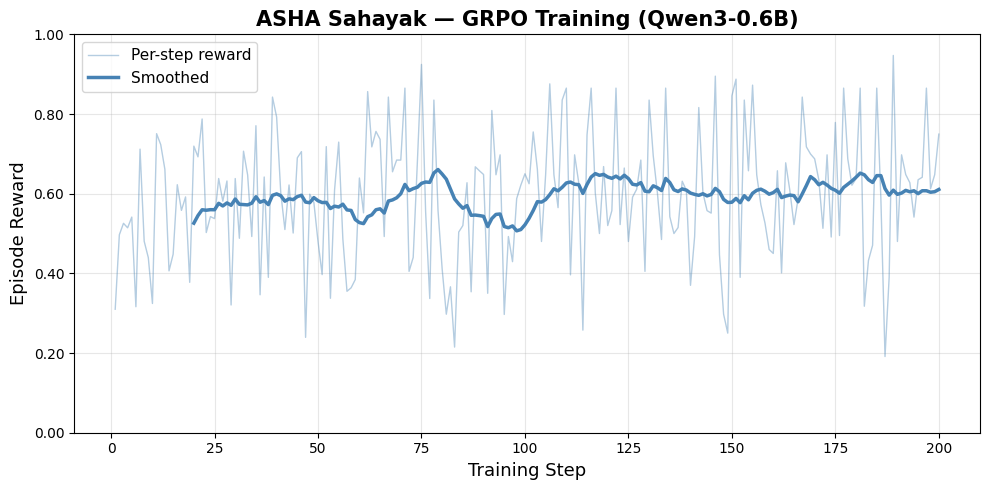

Plot saved: asha_grpo_training_curve.png
Final reward: 0.7495 | Peak: 0.9470
Improvement: +0.4395 (141.8%)


In [7]:
# ── Cell 7: Plot real training curves ─────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

# TRL 1.2.x logs to trainer.state.log_history with key "reward"
# Each log entry looks like: {"step": N, "reward": 0.xxx, "reward_std": 0.xxx, ...}
logs = [l for l in trainer.state.log_history if 'reward' in l]
steps   = [l['step'] for l in logs]
rewards = [l['reward'] for l in logs]

if not rewards:
    print('No reward logs found.')
    print('Available keys in log_history[0]:', list(trainer.state.log_history[0].keys()) if trainer.state.log_history else 'empty')
    print('\nAll log entries:')
    for entry in trainer.state.log_history:
        print(' ', entry)
else:
    print(f'Found {len(rewards)} log points | Reward range: {min(rewards):.4f} – {max(rewards):.4f}')

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(steps, rewards, alpha=0.4, color='steelblue', linewidth=1, label='Per-step reward')

    # Smoothed curve
    if len(rewards) >= 5:
        w = max(3, len(rewards) // 10)
        smoothed = np.convolve(rewards, np.ones(w) / w, mode='valid')
        ax.plot(steps[w - 1:], smoothed, color='steelblue', linewidth=2.5, label='Smoothed')

    ax.set_xlabel('Training Step', fontsize=13)
    ax.set_ylabel('Episode Reward', fontsize=13)
    ax.set_title('ASHA Sahayak — GRPO Training (Qwen3-0.6B)', fontsize=15, fontweight='bold')
    ax.set_ylim(0, 1.0)
    ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('asha_grpo_training_curve.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Plot saved: asha_grpo_training_curve.png')
    print(f'Final reward: {rewards[-1]:.4f} | Peak: {max(rewards):.4f}')
    if len(rewards) > 1:
        improvement = rewards[-1] - rewards[0]
        print(f'Improvement: {improvement:+.4f} ({improvement/max(abs(rewards[0]),1e-6)*100:.1f}%)')

In [8]:
# ── Cell 8: Save and push to HuggingFace Hub ─────────────────────────────────
trainer.save_model(OUTPUT_DIR)
tokenizer.save_pretrained(OUTPUT_DIR)
print(f'Model saved to ./{OUTPUT_DIR}/')

if HF_TOKEN:
    if USE_UNSLOTH:
        # Unsloth: merge LoRA into base weights before pushing
        # Do NOT naively upcast 4-bit to 16-bit — use Unsloth's merge path
        model.save_pretrained_merged(
            OUTPUT_DIR + '_merged',
            tokenizer,
            save_method='merged_16bit',
        )
        model.push_to_hub_merged(
            HF_REPO_ID,
            tokenizer,
            save_method='merged_16bit',
            token=HF_TOKEN,
        )
    else:
        trainer.push_to_hub(repo_id=HF_REPO_ID, token=HF_TOKEN)
    print(f'Model pushed to: https://huggingface.co/{HF_REPO_ID}')
else:
    print('HF_TOKEN not set — model saved locally only.')
    print('To push: set HF_TOKEN and re-run this cell.')

Model saved to ./asha-sahayak-grpo/
Found HuggingFace hub cache directory: /root/.cache/huggingface/hub
Checking cache directory for required files...


Unsloth: Copying 1 files from cache to `asha-sahayak-grpo_merged`: 100%|██████████| 1/1 [00:04<00:00,  4.50s/it]


Successfully copied all 1 files from cache to `asha-sahayak-grpo_merged`
Checking cache directory for required files...
Cache check failed: tokenizer.model not found in local cache.
Not all required files found in cache. Will proceed with downloading.


Unsloth: Merging weights into 16bit: 100%|██████████| 1/1 [00:04<00:00,  4.53s/it]
/usr/local/lib/python3.12/dist-packages/unsloth_zoo/saving_utils.py:1891: UserWarning: Model unsloth/Qwen3-0.6B not found locally or on HuggingFace
  warnings.warn(f"Model {model_name} not found locally or on HuggingFace")


Unsloth: Merge process complete. Saved to `/content/asha-sahayak-grpo_merged`
Model pushed to: https://huggingface.co/sreenathmmenon/asha-sahayak-grpo


In [10]:
from huggingface_hub import HfApi

api = HfApi(token=HF_TOKEN.strip())
api.upload_file(
      path_or_fileobj='asha_grpo_training_curve.png',
      path_in_repo='assets/training_reward_curve.png',
      repo_id='sreenathmmenon/asha-sahayak',
      repo_type='space',
      commit_message='Update training curve with real GRPO results',
)
print('Uploaded!')

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  asha_grpo_training_curve.png: 100%|##########|  130kB /  130kB            

Uploaded!


In [11]:

from huggingface_hub import HfApi
api = HfApi(token=HF_TOKEN.strip())

# Create the repo first
api.create_repo(
      repo_id='sreenathmmenon/asha-sahayak-grpo',
      repo_type='model',
      private=False,
      exist_ok=True,
)

# Push the merged model folder
api.upload_folder(
      folder_path='/content/asha-sahayak-grpo_merged',
      repo_id='sreenathmmenon/asha-sahayak-grpo',
      repo_type='model',
      commit_message='ASHA Sahayak GRPO trained Qwen3-0.6B — 200 steps',
)
print('Done! https://huggingface.co/sreenathmmenon/asha-sahayak-grpo')


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...rpo_merged/tokenizer.json:  30%|###       | 3.46MB / 11.4MB            

  ..._merged/model.safetensors:   4%|4         | 47.9MB / 1.19GB            

Done! https://huggingface.co/sreenathmmenon/asha-sahayak-grpo
